# **FigEngine: A High-Performance Structured Figure Engine**

##### **1. 导入库**

In [17]:
import os
import sys
# 导入FigEngine库
import figengine as fe

# 定义常量
DPI = 600
# 初始化日志记录系统
logger = fe.setup_logger(level="Warning")

##### **2. 创建几个测试的空白的Image对象**

In [18]:
# 创建一个空白的Image对象
img1 = fe.Image.new(size=(6.0, 5.0), facecolor="#F0CED8", unit="inch", dpi=DPI, label="a").labeled(fontsize=14, offset=(0.03, 0.03))
img2 = fe.Image.new(size=(3.0, 5.0), facecolor="#F583A5", unit="inch", dpi=DPI, label="b").labeled(fontsize=14, offset=(0.03, 0.03))
img3 = fe.Image.new(size=(6.0, 2.0), facecolor="#FC739C", unit="inch", dpi=DPI, label="c").labeled(fontsize=14, offset=(0.03, 0.03))
img4 = fe.Image.new(size=(4.0, 4.0), facecolor="#FA5284", unit="inch", dpi=DPI, label="d").labeled(fontsize=14, offset=(0.03, 0.03))
img5 = fe.Image.new(size=(5.0, 5.0), facecolor="#FC2D6B", unit="inch", dpi=DPI, label="e").labeled(fontsize=14, offset=(0.03, 0.03))
img6 = fe.Image.new(size=(2.0, 6.0), facecolor="#FC004C", unit="inch", dpi=DPI, label="f").labeled(fontsize=14, offset=(0.03, 0.03))
img7 = fe.Image.new(size=(6.0, 5.0), facecolor="#BAB3D4", unit="inch", dpi=DPI, label="g").labeled(fontsize=14, offset=(0.03, 0.03))
img8 = fe.Image.new(size=(3.0, 5.0), facecolor="#8E7AC8", unit="inch", dpi=DPI, label="h").labeled(fontsize=14, offset=(0.03, 0.03))
img9 = fe.Image.new(size=(6.0, 2.0), facecolor="#9F6ECF", unit="inch", dpi=DPI, label="i").labeled(fontsize=14, offset=(0.03, 0.03))

##### **3. 创建Figure**
**函数签名:**

`fe.Figure(background, dpi, width, height, unit)`

> ⚠️ **懒加载机制 (Lazy Evaluation)**
>
> `Figure` 只有在调用 `.image` 属性或 `.save()` 方法时才会真正触发渲染。
> 因此，对于 `Figure` 对象，必须先调用 `fig.image` 将其转为 `Image` 对象后，才能进行后续的图片操作（如缩放、旋转、叠加等）。

**参数:**

- `background`: 画布背景颜色
- `dpi`: 输出图像的分辨率, 默认300
- `width`: (可选) 独立指定画布宽度, 如果为 0，宽度将根据内容自动推断, 谨慎使用
- `height`: (可选) 独立指定画布高度, 谨慎使用
- `unit`: 尺寸单位(支持: "pixel", "inch", "cm", "mm"，默认 "inch")

In [19]:
fig = fe.Figure(background="#FFFFFF", dpi=DPI, width=12, unit="inch")
fig.set_margins(top=0.01, bottom=0.01, left=0.01, right=0.01)

##### **4. Figure中添加Image**
**函数签名:**

`Figure.add_row(items, left_gaps, right_gaps, top_margin, bottom_margin, unit, align)`

**参数:**

- `items`: 图片列表, 可以是文件路径字符串，也可以是已加载的 Image 对象
- `left_gaps`: 图片左侧间距, 如果是单个值，应用于该行所有图片；如果是列表，对应每个图片 **(单个值或列表)**
- `right_gaps`: 图片右侧间距, 如果是单个值，应用于该行所有图片；如果是列表，对应每个图片 **(单个值或列表)**
- `top_margin`: 该行距离上一行的间距 **(单个值)**
- `bottom_margin`: 该行距离下一行的间距 **(单个值)**
- `unit`: 单位(支持: "pixel", "ratio", "inch", "cm", "mm"，默认 "ratio")
- `align`: 行内图片的对齐/排版方式
  - `full`:  强制两端对齐 (Justified), 自动缩放图片以等高并填满行宽
  - `top`:  顶部对齐
  - `center`:  垂直居中对齐
  - `bottom`:  底部对齐

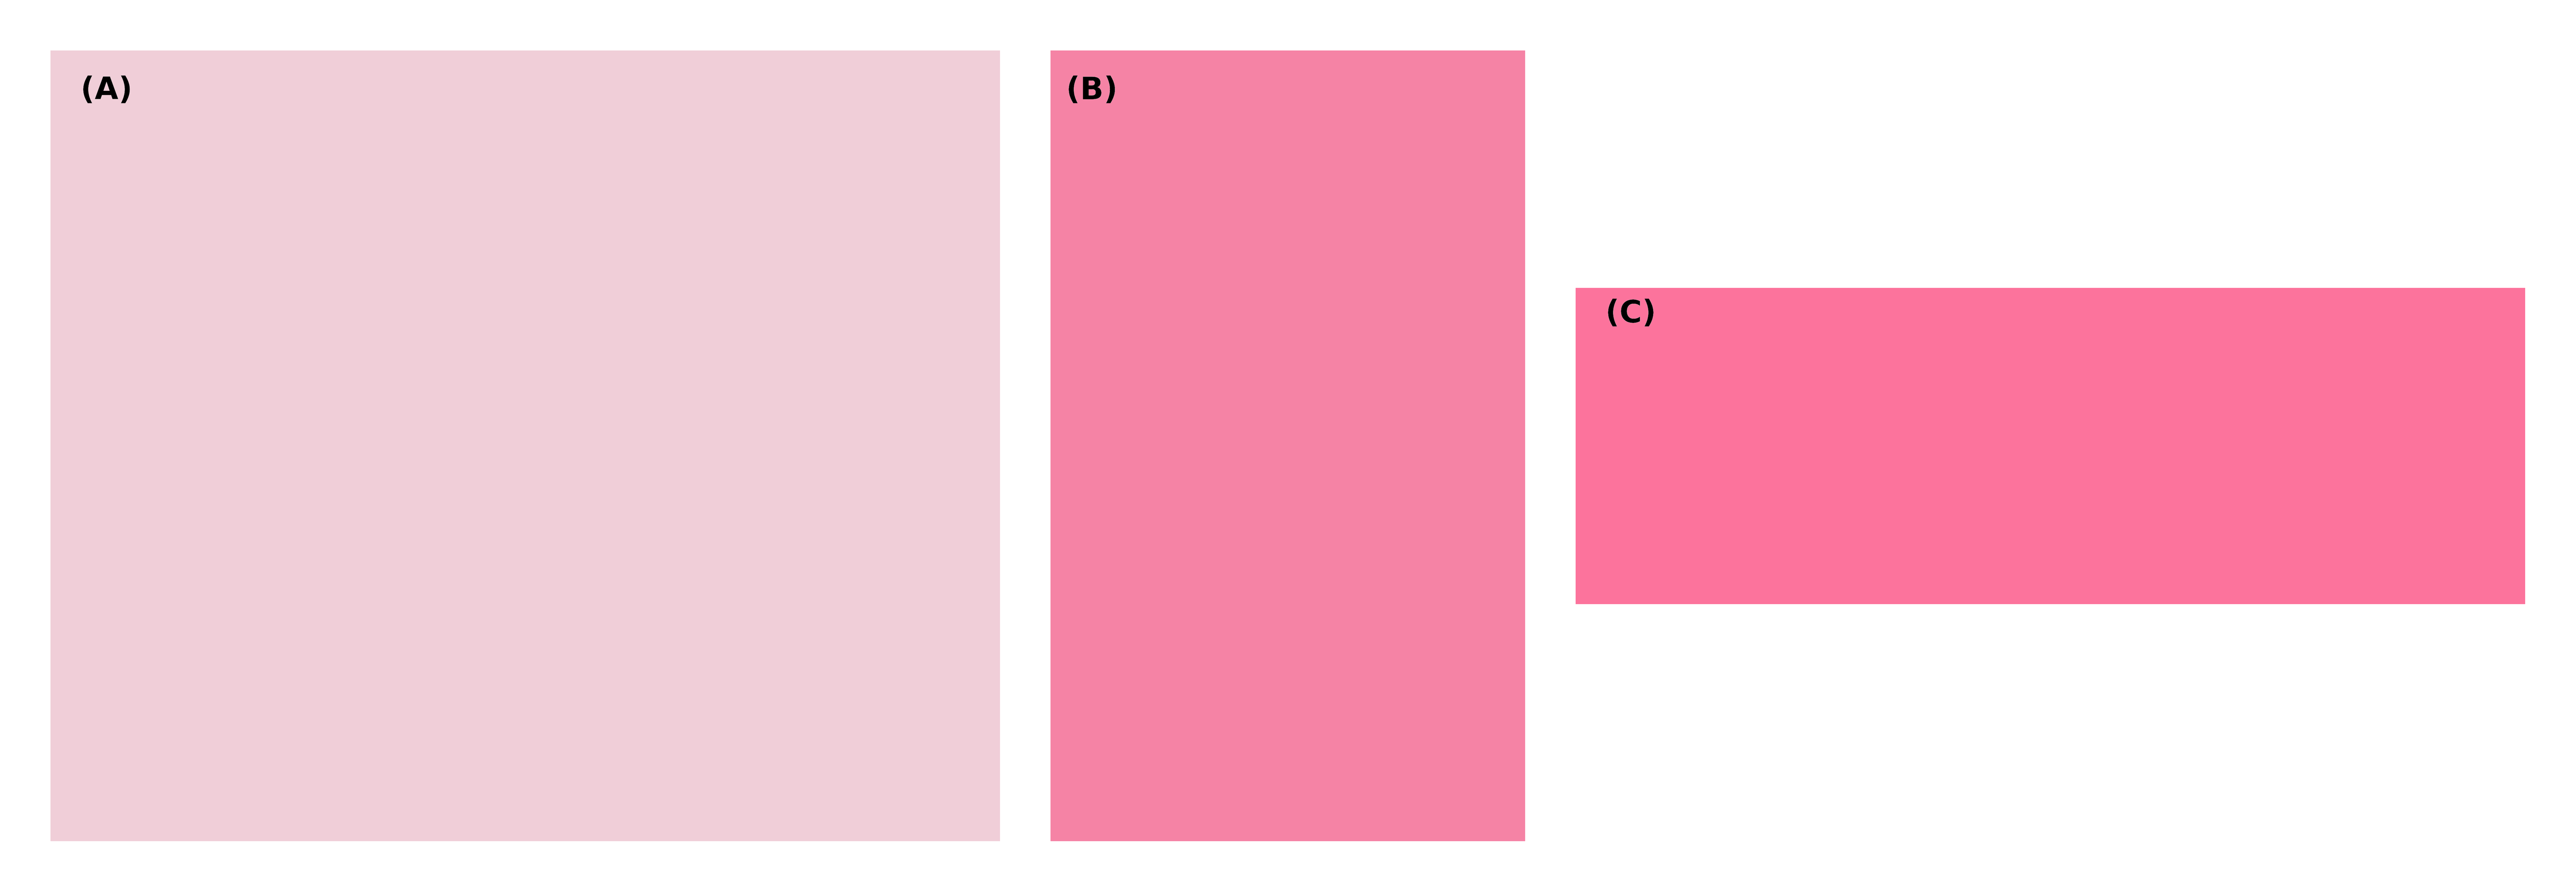

In [20]:
# 第一行
images_row1 = {"items": [img1, img2, img3],
               "left_gaps": [0.01, 0.01, 0.01],
               "right_gaps": [0.01, 0.01, 0.01],
               "top_margin": 0.01,         
               "bottom_margin": 0.01,
               "unit": "ratio",
               "align": "center"}
fig_ = fig.add_row(**images_row1)
fig_.image.show(width=500)

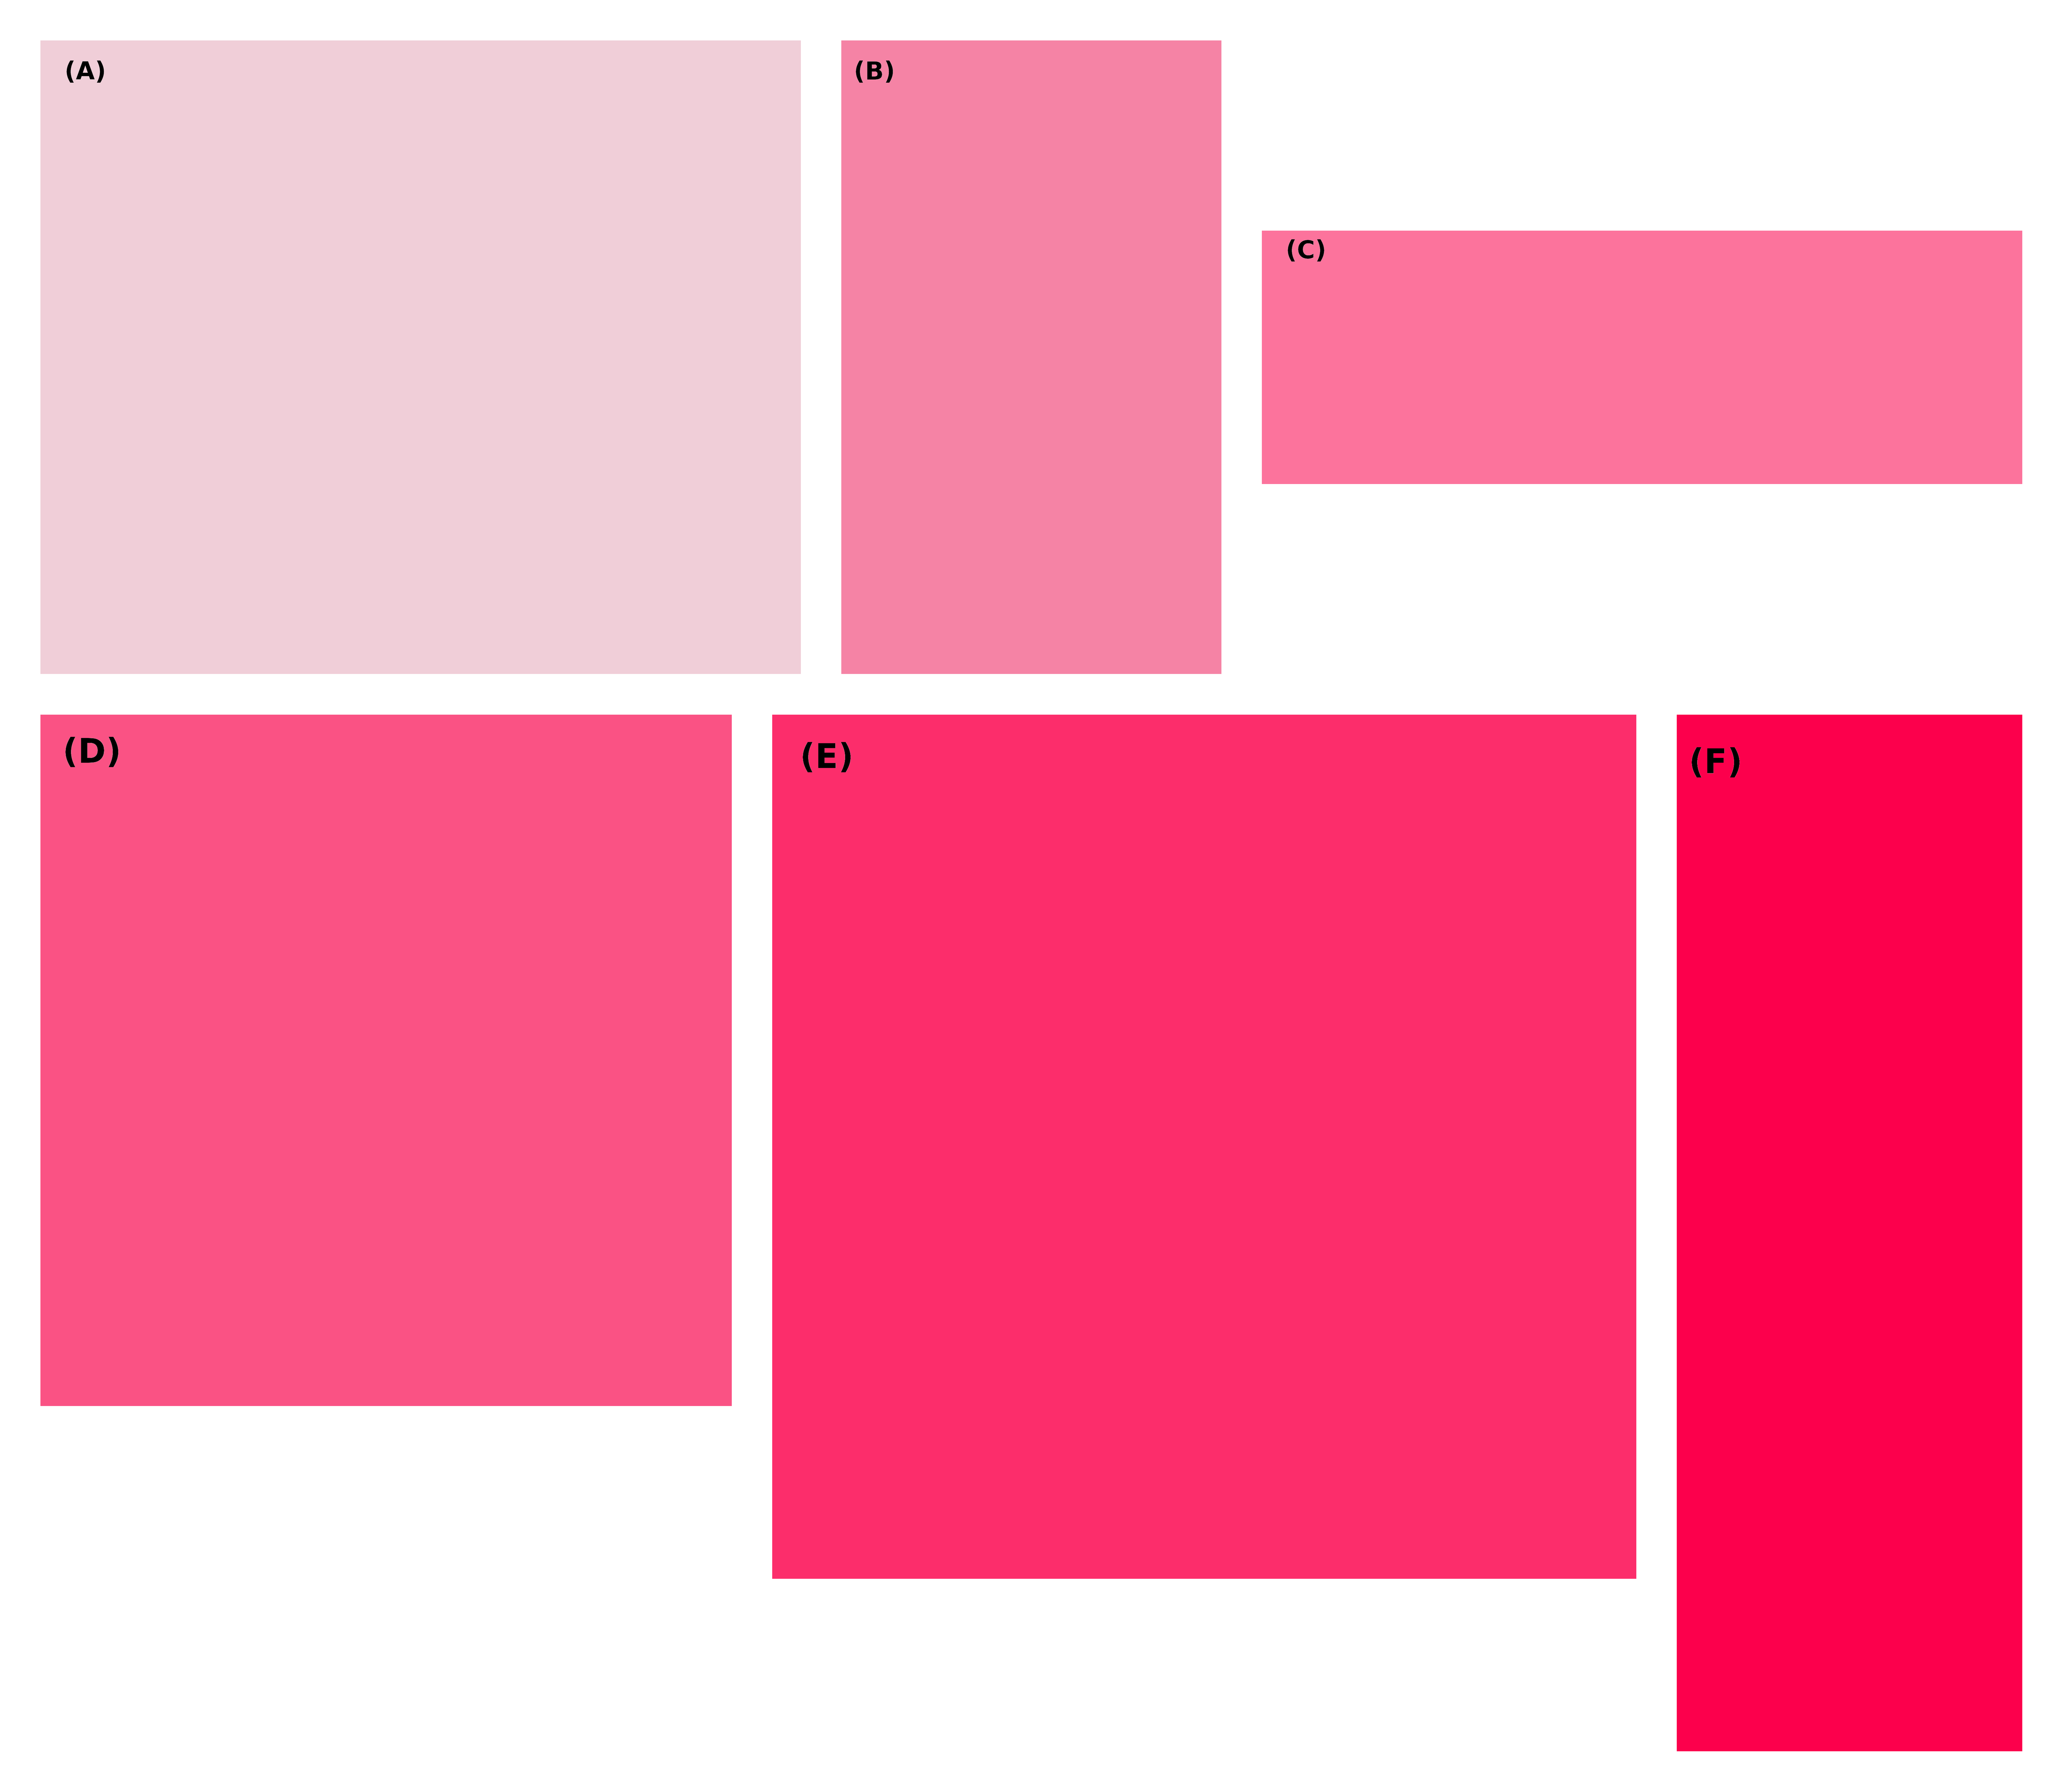

In [21]:
# 第二行
images_row2 = {"items": [img4, img5, img6],
               "left_gaps": [0.01, 0.01, 0.01],
               "right_gaps": [0.01, 0.01, 0.01],
               "top_margin": 0.01,         
               "bottom_margin": 0.01,
               "unit": "ratio",
               "align": "top"}
fig.add_row(**images_row2)

fig.image.show(width=500)

In [22]:
# 复制第二行并强制拉伸到等高
images_row2 = {"items": [img4, img5, img6],
               "left_gaps": [0.01, 0.01, 0.01],
               "right_gaps": [0.01, 0.01, 0.01],
               "top_margin": 0.01,         
               "bottom_margin": 0.01,
               "unit": "ratio",
               "align": "full"}  # 强制缩放所有图到等高
fig.add_row(**images_row2)
fig.image.show(width=500)

In [23]:
# 复制第二行并强制拉伸到等高
images_row2 = {"items": [img7, img8, img9],
               "left_gaps": [0.01, 0.01, 0.01],
               "right_gaps": [0.01, 0.01, 0.01],
               "top_margin": 0.01,         
               "bottom_margin": 0.01,
               "unit": "ratio",
               "align": "bottom"}  # 强制缩放所有图到等高
fig.add_row(**images_row2)
fig.image.show(width=500)


##### **5. 删除某一行**
**函数签名:**

`Figure.remove_row(index)`

**参数:**

- `index`: 指定索引处的行, 从0开始

In [24]:
# 删除第一行
fig.remove_row(index=0)
fig.image.show(width=500)

##### **6. 替换Figure中的某一行**
**函数签名:**

`Figure.replace_row(index, items, left_gaps, right_gaps, top_margin, bottom_margin, unit, align)`

**参数:**

- `index`: 要替换的行的从 0 开始的索引
- `items`: 图片列表, 可以是文件路径字符串，也可以是已加载的 Image 对象
- `left_gaps`: 图片左侧间距, 如果是单个值，应用于该行所有图片；如果是列表，对应每个图片 **(单个值或列表)**
- `right_gaps`: 图片右侧间距, 如果是单个值，应用于该行所有图片；如果是列表，对应每个图片 **(单个值或列表)**
- `top_margin`: 该行距离上一行的间距 **(单个值)**
- `bottom_margin`: 该行距离下一行的间距 **(单个值)**
- `unit`: 单位(支持: "pixel", "ratio", "inch", "cm", "mm"，默认 "ratio")
- `align`: 行内图片的对齐/排版方式
  - `full`:  强制两端对齐 (Justified), 自动缩放图片以等高并填满行宽
  - `top`:  顶部对齐
  - `center`:  垂直居中对齐
  - `bottom`:  底部对齐

In [25]:
# 替换第一行
fig.replace_row(0, **images_row1)
fig.image.show(width=500)

##### **7. 保存图片**

**函数签名:**

`Figure.save(path, **kwargs)`

**参数:**

- `path`: 输出文件路径 (e.g. "output/fig1.png"), 需要带格式后缀
- `**kwargs`: 额外参数, 例如 quality=95 (JPG), compression="tiff_lzw" (TIFF) 等

In [26]:
fig.save("./assets/figure_layout_output.png")
fig.save("./assets/figure_layout_output.pdf")